<a href="https://colab.research.google.com/github/Sudhanshu-32/Machine_Learning/blob/main/SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**CUSTOMER CHURN PREDICTION USING SUPPORT VECTOR MACHINE (SVM)**

### Importing necessary libraries

In [ ]:
import pandas as pd
#import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Loading the dataset from Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

df=pd.read_excel('/content/drive/MyDrive/ecommerce_dataset/E Commerce Dataset.xlsx')
df.shape

Mounted at /content/drive


(5630, 20)

### Displaying the first few rows of the DataFrame

In [ ]:
df.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


### Displaying the last few rows of the DataFrame

In [ ]:
df.tail()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
5625,55626,0,10.0,Computer,1,30.0,Credit Card,Male,3.0,2,Laptop & Accessory,1,Married,6,0,18.0,1.0,2.0,4.0,150.71
5626,55627,0,13.0,Mobile Phone,1,13.0,Credit Card,Male,3.0,5,Fashion,5,Married,6,0,16.0,1.0,2.0,NaN,224.91
5627,55628,0,1.0,Mobile Phone,1,11.0,Debit Card,Male,3.0,2,Laptop & Accessory,4,Married,3,1,21.0,1.0,2.0,4.0,186.42
5628,55629,0,23.0,Computer,3,9.0,Credit Card,Male,4.0,5,Laptop & Accessory,4,Married,4,0,15.0,2.0,2.0,9.0,178.90
5629,55630,0,8.0,Mobile Phone,1,15.0,Credit Card,Male,3.0,2,Laptop & Accessory,3,Married,4,0,13.0,2.0,2.0,3.0,169.04


### Getting a concise summary of the DataFrame

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   object 
 13  NumberOfAddress   

### Generating descriptive statistics of the DataFrame

In [ ]:
df.describe()

,CustomerID,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
count,5630.000000,5630.000000,5366.000000,5630.000000,5379.000000,5375.000000,5630.000000,5630.000000,5630.000000,5630.000000,5365.000000,5374.000000,5372.000000,5323.000000,5630.000000
mean,52815.500000,0.168384,10.189899,1.654707,15.639896,2.931535,3.688988,3.066785,4.214032,0.284902,15.707922,1.751023,3.008004,4.543491,177.223030
std,1625.385339,0.374240,8.557241,0.915389,8.531475,0.721926,1.023999,1.380194,2.583586,0.451408,3.675485,1.894621,2.939680,3.654433,49.207036
min,50001.000000,0.000000,0.000000,1.000000,5.000000,0.000000,1.000000,1.000000,1.000000,0.000000,11.000000,0.000000,1.000000,0.000000,0.000000
25%,51408.250000,0.000000,2.000000,1.000000,9.000000,2.000000,3.000000,2.000000,2.000000,0.000000,13.000000,1.000000,1.000000,2.000000,145.770000
50%,52815.500000,0.000000,9.000000,1.000000,14.000000,3.000000,4.000000,3.000000,3.000000,0.000000,15.000000,1.000000,2.000000,3.000000,163.280000
75%,54222.750000,0.000000,16.000000,3.000000,20.000000,3.000000,4.000000,4.000000,6.000000,1.000000,18.000000,2.000000,3.000000,7.000000,196.392500
max,55630.000000,1.000000,61.000000,3.000000,127.000000,5.000000,6.000000,5.000000,22.000000,1.000000,26.000000,16.000000,16.000000,46.000000,324.990000


### Checking for missing values in each column

In [ ]:
df.isnull().sum()

,0
Churn,0
Tenure,0
PreferredLoginDevice,0
CityTier,0
WarehouseToHome,0
PreferredPaymentMode,0
Gender,0
HourSpendOnApp,0
NumberOfDeviceRegistered,0
PreferedOrderCat,0


### Checking for duplicate rows in the DataFrame

In [ ]:
df.duplicated().sum()


np.int64(0)

### Filling missing values with the median

In [ ]:
null_cols=['Tenure','WarehouseToHome','HourSpendOnApp','OrderAmountHikeFromlastYear','CouponUsed','OrderCount','DaySinceLastOrder']
df[null_cols]=df[null_cols].fillna(df[null_cols].median())
df.isnull().sum()

,0
Churn,0
Tenure,0
PreferredLoginDevice,0
CityTier,0
WarehouseToHome,0
PreferredPaymentMode,0
Gender,0
HourSpendOnApp,0
NumberOfDeviceRegistered,0
PreferedOrderCat,0


### Displaying the DataFrame after filling null values

In [ ]:
df.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,9.0,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,9.0,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,3.0,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


### Replacing inconsistent categorical values

In [ ]:
df['PreferredLoginDevice']=df['PreferredLoginDevice'].replace({'Phone':'Mobile Phone'})
df['PreferredPaymentMode']=df['PreferredPaymentMode'].replace({'CC':'Credit Card','COD':'Cash on Delivery'})
df['PreferedOrderCat']=df['PreferedOrderCat'].replace({'Mobile':'Mobile Phone'})
for c in ['PreferredLoginDevice','PreferredPaymentMode','PreferedOrderCat']:
  print(df[c].value_counts(),'\n')

PreferredLoginDevice
Mobile Phone    3996
Computer        1634
Name: count, dtype: int64 

PreferredPaymentMode
Debit Card          2314
Credit Card         1774
E wallet             614
Cash on Delivery     514
UPI                  414
Name: count, dtype: int64 

PreferedOrderCat
Mobile Phone          2080
Laptop & Accessory    2050
Fashion                826
Grocery                410
Others                 264
Name: count, dtype: int64 



#checking the distribution

### Visualizing the Churn distribution

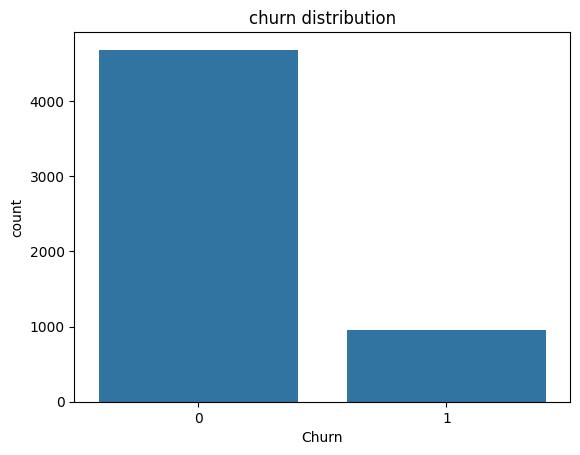

Churn
0    4682
1     948
Name: count, dtype: int64
Churn
0    0.832
1    0.168
Name: proportion, dtype: float64


In [ ]:
sns.countplot(x='Churn',data=df)
plt.title('churn distribution')
plt.show()
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True).round(3))

### Visualizing Tenure distribution by Churn

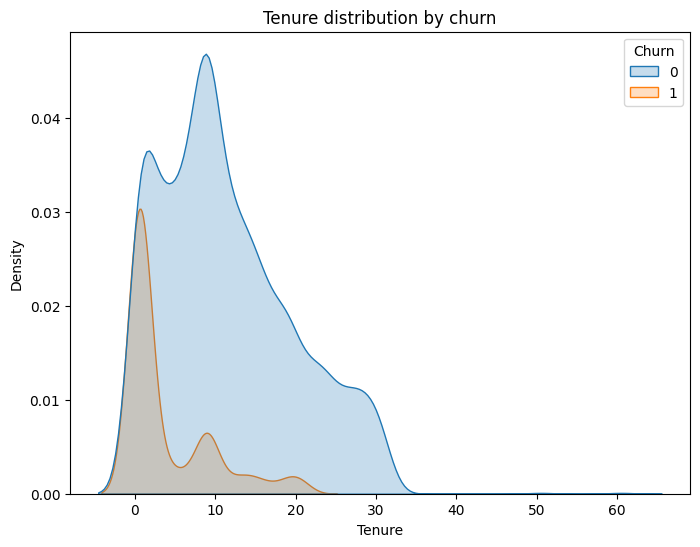

,Tenure
Churn,
0,10.0
1,1.0


In [ ]:
# plotting kde plot
plt.figure(figsize=(8,6))
sns.kdeplot(data=df,x='Tenure',hue='Churn',fill=True)
plt.title('Tenure distribution by churn')
plt.show()
df.groupby('Churn')['Tenure'].median()

### Analyzing Churn rate by Complain status

In [ ]:

df.groupby('Complain')['Churn'].mean()

,Churn
Complain,
0,0.109290
1,0.316708


### Analyzing Churn rate by Satisfaction Score

In [ ]:
df.groupby('SatisfactionScore')['Churn'].mean()

,Churn
SatisfactionScore,
1,0.115120
2,0.126280
3,0.171967
4,0.171322
5,0.238267


### Visualizing correlations between numerical features with a heatmap

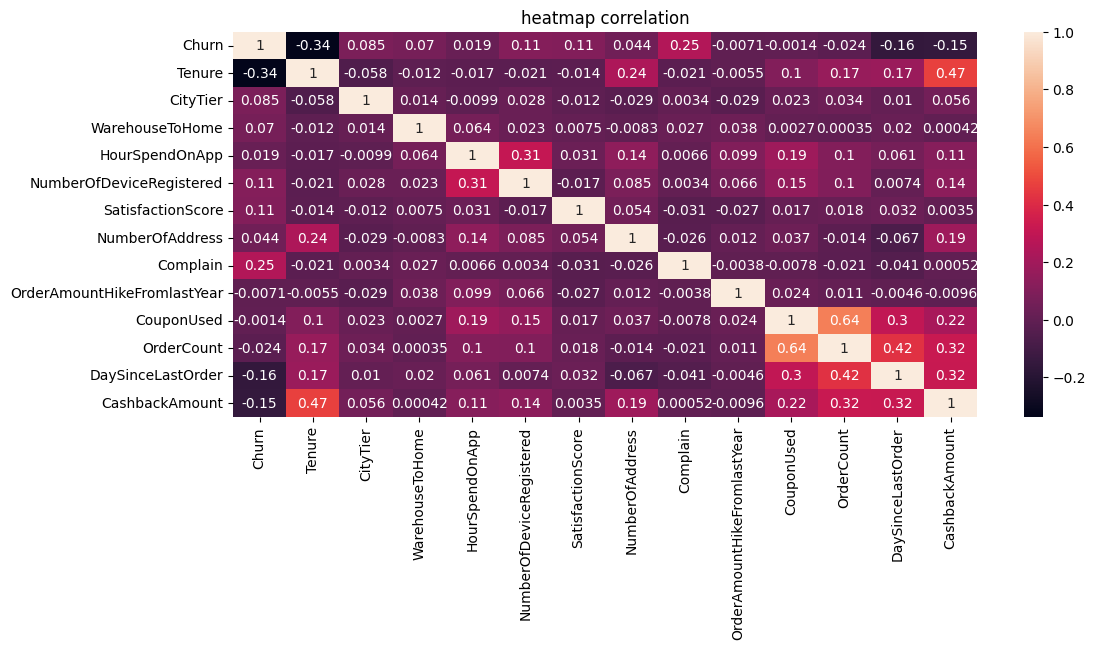

In [ ]:
plt.figure(figsize=(12,5))
sns.heatmap(df.select_dtypes('number').corr(),annot=True)
plt.title('heatmap correlation')
plt.show()

# **FINDINGS AFTER PERFORMING EDA(Cleaning and Transformation)**
#1.Customers churn highly depends on tenure means new customers are more likely to churn  
#2.It also depends on number of complaint means when complaint increases,churn increases

### Importing scikit-learn modules for model building and evaluation

In [ ]:
# import scikit learn modules
from sklearn.model_selection import train_test_split
# from sklearn.linear_model import

from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## Feature Engineering: Encoding Categorical Variables

## Data Splitting: Training and Testing Sets

In [ ]:
X = df.drop(columns='Churn')
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(X_train.shape, X_test.shape)

(4504, 18) (1126, 18)


### Encoding categorical features using one-hot encoding

In [ ]:
cat_features = X.select_dtypes('object').columns.tolist()
X_encoded = pd.get_dummies(X, columns=cat_features, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, stratify=y, random_state=42
)

print(X_train.shape, X_test.shape)
X_train.head()

(4504, 25) (1126, 25)


,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,...,PreferredPaymentMode_Debit Card,PreferredPaymentMode_E wallet,PreferredPaymentMode_UPI,Gender_Male,PreferedOrderCat_Grocery,PreferedOrderCat_Laptop & Accessory,PreferedOrderCat_Mobile Phone,PreferedOrderCat_Others,MaritalStatus_Married,MaritalStatus_Single
1787,9.0,3,16.0,2.0,3,1,2,0,14.0,8.0,...,False,False,False,True,False,False,False,False,False,True
2147,6.0,3,13.0,1.0,3,4,1,0,17.0,0.0,...,True,False,False,False,False,True,False,False,True,False
1717,8.0,1,15.0,3.0,4,4,10,0,19.0,0.0,...,True,False,False,True,False,True,False,False,False,True
2292,15.0,3,11.0,3.0,3,4,10,1,19.0,7.0,...,True,False,False,True,False,False,False,False,False,True
5578,12.0,1,13.0,4.0,5,3,4,0,12.0,3.0,...,True,False,False,True,False,True,False,False,True,False


### Scaling numerical features using StandardScaler

In [ ]:

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled[:2])

[[-0.13539837  1.45355915  0.04317737 -1.32571137 -0.67597586 -1.49357337
  -0.85675503 -0.62391176 -0.46885848  3.38663463  2.15796428  0.71575405
   0.45659281 -1.56314589  1.4790349  -0.8326062  -0.35773447 -0.28255437
   0.82270462 -0.28117762 -0.75563226 -0.76071618 -0.21837012 -1.07328236
   1.46842497]
 [-0.49475857  1.45355915 -0.31896575 -2.74265584 -0.67597586  0.67388054
  -1.24665345 -0.62391176  0.36648116 -0.9265005  -0.68357091 -0.69101687
  -0.70003053 -1.56314589 -0.67611657  1.20104799 -0.35773447 -0.28255437
  -1.21550308 -0.28117762  1.32339505 -0.76071618 -0.21837012  0.93172127
  -0.68100177]]


### Initializing and training the SVM model with original parameters

In [ ]:
from sklearn.svm import SVC

# Initialize and train the SVM model with the original parameters
svm_model = SVC(kernel='rbf', class_weight='balanced')
svm_model.fit(X_train_scaled, y_train)

SVC(class_weight='balanced')

### Making predictions on the test set

In [ ]:
y_pred = svm_model.predict(X_test_scaled)
y_pred

array([0, 0, 0, ..., 0, 0, 0])

### Evaluating the model's accuracy

In [ ]:
print("Accuracy :", accuracy_score(y_test, y_pred))

Accuracy : 0.8952042628774423


### Displaying the confusion matrix

In [ ]:
print(confusion_matrix(y_test, y_pred))

[[831 105]
 [ 13 177]]


### Displaying the classification report

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.89      0.93       936
           1       0.63      0.93      0.75       190

    accuracy                           0.90      1126
   macro avg       0.81      0.91      0.84      1126
weighted avg       0.92      0.90      0.90      1126

